In [2]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import pvlib
import json
import numpy as np
import scipy.optimize as optimize
from scipy import stats
import scipy.stats as stats
import calendar

data, meta, inputs = pvlib.iotools.get_pvgis_hourly(9.040,12.7222,start=2005,end=2020,url='https://re.jrc.ec.europa.eu/api/v5_2/',
                                                    raddatabase='PVGIS-SARAH2',components=False,outputformat='json',pvcalculation=True,peakpower=1,
                                                    pvtechchoice='crystSi',mountingplace='free',loss=0,optimalangles=True,map_variables=True)

df = pd.DataFrame(data)
# Extract month and hour from the index
df['Month'] = df.index.month
df['Hour'] = df.index.hour

#change the function for allowing other timesteps


In [3]:
def get_hourly_distributions(df):
    hourly_distributions = {}

    # Iterate over unique hours in the dataframe
    unique_hours = df['Hour'].unique()
    for hour in unique_hours:
        hourly_distributions[hour] = {}

        # Iterate over unique months in the dataframe
        unique_months = df['Month'].unique()
        for month in unique_months:
            # Filter the data for the given month and hour
            filtered_data = df[(df['Month'] == month) & (df['Hour'] == hour)]['P']

            # Select the distribution and create the distribution object
            distribution = stats.johnsonsu

            params = distribution.fit(filtered_data)
            dist = distribution(*params[:-2], loc=params[-2], scale=params[-1])  # Corrected line

            # Store the distribution for the hour and month
            hourly_distributions[hour][month] = dist

    return hourly_distributions

def generate_scenario_data(df, hourly_distributions):
    dfs = []

    # Generate data for each month and hour of the year
    for month in range(1, 13):
        _, num_days = calendar.monthrange(2023, month)

        for day in range(1, num_days + 1):
            for hour in range(24):
                dist = hourly_distributions[hour][month]

                # Generate a random value from the Johnson SU distribution
                value = dist.rvs()

                # Replace negative value with 0
                value = max(0, value)

                # Create the DateTime index for the current hour of the year
                date_time = pd.to_datetime(f'2023-{month:02d}-{day:02d} {hour:02d}:00:00')

                # Append the value to the list of dataframes
                df_hourly = pd.DataFrame({'P': [value]}, index=[date_time])
                dfs.append(df_hourly)

    # Concatenate all dataframes into a single dataframe
    df_yearly = pd.concat(dfs)

    # Round the 'P' values to the nearest decimal
    df_yearly['P'] = df_yearly['P'].round(1)

    return df_yearly

def generate_scenarios(df, s):
    # Calculate hourly distributions for the entire year
    hourly_distributions = get_hourly_distributions(df)

    scenarios = []

    for i in range(1, s + 1):
        # Generate scenario data
        df_scenario = generate_scenario_data(df, hourly_distributions)

        # Save the scenario data to a CSV file
        df_scenario.to_csv(f'scenario_{i}.csv', index=False)

        scenarios.append(df_scenario)

        print(f"Scenario {i} generated successfully.")

    # Concatenate all scenarios into a single dataframe
    df_all_scenarios = pd.concat(scenarios)

    return df_all_scenarios

# Load your initial DataFrame (df) here

# Specify the number of scenarios
num_scenarios = 20

# Generate the scenarios and get the dataframe with all scenarios
df_all_scenarios = generate_scenarios(df, num_scenarios)

# Print the dataframe with all scenarios
print(df_all_scenarios)


Scenario 1 generated successfully.
Scenario 2 generated successfully.
Scenario 3 generated successfully.
Scenario 4 generated successfully.
Scenario 5 generated successfully.
Scenario 6 generated successfully.
Scenario 7 generated successfully.
Scenario 8 generated successfully.
Scenario 9 generated successfully.
Scenario 10 generated successfully.
Scenario 11 generated successfully.
Scenario 12 generated successfully.
Scenario 13 generated successfully.
Scenario 14 generated successfully.
Scenario 15 generated successfully.
Scenario 16 generated successfully.
Scenario 17 generated successfully.
Scenario 18 generated successfully.
Scenario 19 generated successfully.
Scenario 20 generated successfully.
                       P
2023-01-01 00:00:00  0.0
2023-01-01 01:00:00  0.0
2023-01-01 02:00:00  0.0
2023-01-01 03:00:00  0.0
2023-01-01 04:00:00  0.0
...                  ...
2023-12-31 19:00:00  0.0
2023-12-31 20:00:00  0.0
2023-12-31 21:00:00  0.0
2023-12-31 22:00:00  0.0
2023-12-31 23:

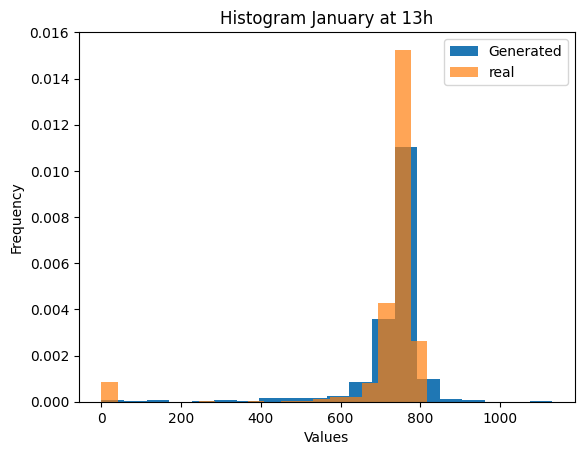

In [10]:
dfo=df_all_scenarios

dfo['Month'] = dfo.index.month
dfo['Hour'] = dfo.index.hour

month = 1
hour = 13

filtered_data = dfo[(dfo['Month'] == month) & (dfo['Hour'] == hour)]['P']

df['Month'] = df.index.month
df['Hour'] = df.index.hour

filtered_data = dfo[(dfo['Month'] == month) & (dfo['Hour'] == hour)]['P']
filtered_data2 = df[(df['Month'] == month) & (df['Hour'] == hour)]['P']

# Plotting the histogram
plt.hist(filtered_data, bins=20, density=True, label = 'Generated')
plt.hist(filtered_data2, bins=20,alpha=0.7, density=True, label = 'real')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram January at 13h')


plt.legend()
plt.show()

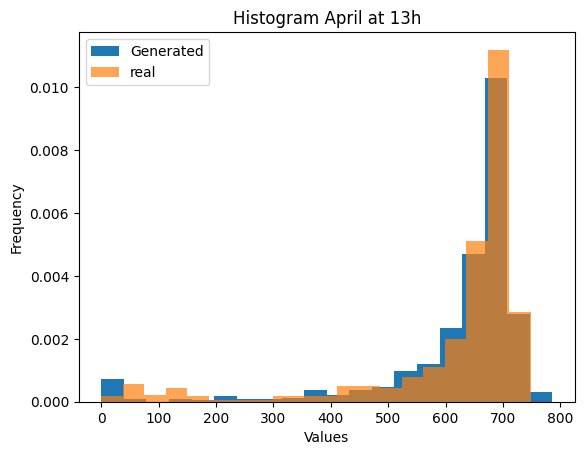

In [11]:
month = 4
hour = 13

filtered_data = dfo[(dfo['Month'] == month) & (dfo['Hour'] == hour)]['P']

filtered_data = dfo[(dfo['Month'] == month) & (dfo['Hour'] == hour)]['P']
filtered_data2 = df[(df['Month'] == month) & (df['Hour'] == hour)]['P']

# Plotting the histogram
plt.hist(filtered_data, bins=20, density=True, label = 'Generated')
plt.hist(filtered_data2, bins=20,alpha=0.7, density=True, label = 'real')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram April at 13h')


plt.legend()
plt.show()

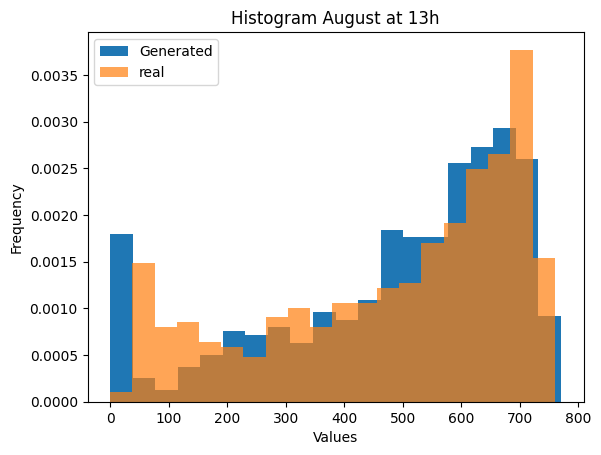

In [12]:
month = 8
hour = 13

filtered_data = dfo[(dfo['Month'] == month) & (dfo['Hour'] == hour)]['P']

filtered_data = dfo[(dfo['Month'] == month) & (dfo['Hour'] == hour)]['P']
filtered_data2 = df[(df['Month'] == month) & (df['Hour'] == hour)]['P']

# Plotting the histogram
plt.hist(filtered_data, bins=20, density=True, label = 'Generated')
plt.hist(filtered_data2, bins=20,alpha=0.7, density=True, label = 'real')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram August at 13h')


plt.legend()
plt.show()

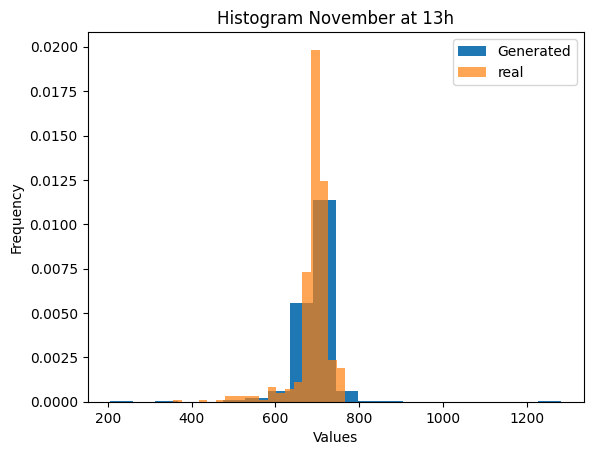

In [13]:
month = 11
hour = 13

filtered_data = dfo[(dfo['Month'] == month) & (dfo['Hour'] == hour)]['P']

filtered_data = dfo[(dfo['Month'] == month) & (dfo['Hour'] == hour)]['P']
filtered_data2 = df[(df['Month'] == month) & (df['Hour'] == hour)]['P']

# Plotting the histogram
plt.hist(filtered_data, bins=20, density=True, label = 'Generated')
plt.hist(filtered_data2, bins=20,alpha=0.7, density=True, label = 'real')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram November at 13h')


plt.legend()
plt.show()